# 03 — Synthetic YOLO dataset generator (+ augmentation)

Composites transparent snack cutouts from all 4 classes
(`dataset/{bar,bear,juice,welchs}-{1..4}-nobg/`) onto 4 real photos of the
actual cardboard tray (`dataset/bg1.png` beige floor, `bg2.png` white
surface, `bg3.jpg` wood table, `bg4` speckled granite — angled shots),
writing YOLO-format `images/{train,val}`, `labels/{train,val}`, `data.yaml`.

- **Deterministic 4x pairing** — each of the 2048 foreground sources is
  composited against all 4 backgrounds (in a per-source-shuffled order), not
  drawn via random sampling with replacement, so every source and background
  is used exactly the same number of times. Independent per-pair
  augmentation (rotation, flip, lighting, blur/noise) is what actually
  supplies pose/lighting variety.
- **Area-based scale** — object bbox area targets ~10% of the frame
  (`SCALE_AREA_RANGE`), matching real tray proportions, instead of a fixed
  fraction of frame width.
- **Grouped, class-stratified train/val split at generation time** — split
  is computed over source stems (e.g. `bar_0001`), not per generated image,
  so the 4 background-variant composites of one photo never end up split
  across train and val (which would leak near-duplicates and inflate val
  mAP).
- Random placement across the full frame, including partial edge overlap;
  lighting jitter (brightness/contrast/saturation); optional post-composite
  blur/noise to simulate motion + sensor noise.


In [1]:
import os
import math
import random
from collections import defaultdict
import yaml
from PIL import Image, ImageEnhance, ImageFilter, UnidentifiedImageError
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches


## Config

In [2]:
DATASET_ROOT = "../dataset"

# Real photos of the actual cardboard tray. bg4 has no file extension despite
# being a real JPEG, so this must be an explicit list — an extension-based
# glob would silently drop it.
BACKGROUND_FILES = [
    os.path.join(DATASET_ROOT, "bg1.png"),
    os.path.join(DATASET_ROOT, "bg2.png"),
    os.path.join(DATASET_ROOT, "bg3.jpg"),
    os.path.join(DATASET_ROOT, "bg4"),
]

OUTPUT_FOLDER = "snacks_yolo_dataset"
VAL_FRACTION = 0.2
SEED = 42  # used both for the source-stem train/val split and to seed augmentation RNG

# Augmentation ranges (tune these against what you observe on the real tray)
SCALE_AREA_RANGE = (0.07, 0.13)     # object bbox area as a fraction of background area (~10% target)
ROTATION_RANGE = (0, 360)           # degrees
FLIP_PROB = 0.5
ALLOW_EDGE_OVERLAP = True           # if True, object may be partially cropped by the frame edge
EDGE_OVERLAP_FRACTION = 0.25        # max fraction of the object allowed to hang off-frame

BRIGHTNESS_RANGE = (0.7, 1.3)
CONTRAST_RANGE = (0.8, 1.2)
SATURATION_RANGE = (0.7, 1.3)

BLUR_PROB = 0.15
BLUR_RADIUS_RANGE = (0.5, 1.5)
NOISE_PROB = 0.25
NOISE_SIGMA_RANGE = (2, 8)  # in 0-255 pixel value units


## Foreground discovery + grouped train/val split

Walks all `dataset/*-nobg` folders. Class = filename prefix before the first
`_` (e.g. `bar_0001.png` -> `bar`), NOT the folder name — `bar-1-nobg` ..
`bar-4-nobg` are 4 photo-session batches of the same class, not 4 classes.

The split is computed once per source stem (e.g. `bar_0001`), stratified per
class, so all 4 background composites of a given source land in the same
split.


In [3]:
def discover_foreground_sources(dataset_root):
    """Return {class_name: [(path, stem), ...]}, sorted, from all *-nobg folders."""
    sources_by_class = defaultdict(list)
    nobg_dirs = sorted(
        d for d in os.listdir(dataset_root)
        if os.path.isdir(os.path.join(dataset_root, d)) and d.endswith("-nobg")
    )
    for d in nobg_dirs:
        dir_path = os.path.join(dataset_root, d)
        for fname in sorted(os.listdir(dir_path)):
            if not fname.lower().endswith(".png"):
                continue
            stem = os.path.splitext(fname)[0]
            class_name = stem.split("_")[0]
            sources_by_class[class_name].append((os.path.join(dir_path, fname), stem))
    return dict(sorted(sources_by_class.items()))


def compute_split(sources_by_class, val_fraction, seed):
    """Return {stem: "train"|"val"}, stratified per class."""
    split_by_stem = {}
    rng = random.Random(seed)
    for class_name, items in sources_by_class.items():
        stems = [stem for _, stem in items]
        shuffled = stems[:]
        rng.shuffle(shuffled)
        n_val = round(len(shuffled) * val_fraction)
        val_stems = set(shuffled[:n_val])
        for stem in stems:
            split_by_stem[stem] = "val" if stem in val_stems else "train"
    return split_by_stem


## Augmentation helpers

In [4]:
def augment_foreground_pose(fg_cropped):
    """Rotate + flip the cutout, then re-tighten the bounding box against the new alpha mask."""
    if random.random() < FLIP_PROB:
        fg_cropped = fg_cropped.transpose(Image.FLIP_LEFT_RIGHT)

    angle = random.uniform(*ROTATION_RANGE)
    rotated = fg_cropped.rotate(angle, resample=Image.BICUBIC, expand=True)

    tight_bbox = rotated.getbbox()
    if not tight_bbox:
        return None
    return rotated.crop(tight_bbox)


def augment_lighting(fg_rgba):
    """Jitter brightness/contrast/saturation on the RGB channels only, alpha untouched."""
    rgb = fg_rgba.convert("RGB")
    alpha = fg_rgba.getchannel("A")

    rgb = ImageEnhance.Brightness(rgb).enhance(random.uniform(*BRIGHTNESS_RANGE))
    rgb = ImageEnhance.Contrast(rgb).enhance(random.uniform(*CONTRAST_RANGE))
    rgb = ImageEnhance.Color(rgb).enhance(random.uniform(*SATURATION_RANGE))

    out = rgb.convert("RGBA")
    out.putalpha(alpha)
    return out


def augment_composite(bg_img):
    """Simulate camera/motion effects on the whole scene after compositing."""
    if random.random() < BLUR_PROB:
        bg_img = bg_img.filter(ImageFilter.GaussianBlur(radius=random.uniform(*BLUR_RADIUS_RANGE)))

    if random.random() < NOISE_PROB:
        arr = np.array(bg_img).astype(np.int16)
        sigma = random.uniform(*NOISE_SIGMA_RANGE)
        noise = np.random.normal(0, sigma, arr.shape)
        arr = np.clip(arr + noise, 0, 255).astype(np.uint8)
        bg_img = Image.fromarray(arr)

    return bg_img


## Core generator

For each foreground source, pairs it with all 4 backgrounds (shuffled order
per source) and independently augments each pair (pose, lighting,
composite). On a failed candidate (empty bbox after rotation, degenerate
placement bounds, etc.) only the augmentation is retried — the `(fg, bg)`
pair itself is fixed, so every pair eventually yields exactly one image and
the total count is deterministic (sources x 4).


In [5]:
def generate_synthetic_yolo_dataset(
    fg_class_dirs=None,
    background_files=None,
    output_folder=None,
    val_fraction=None,
    seed=None,
    max_sources_per_class=None,
):
    fg_class_dirs = fg_class_dirs or DATASET_ROOT
    background_files = background_files or BACKGROUND_FILES
    output_folder = output_folder or OUTPUT_FOLDER
    val_fraction = VAL_FRACTION if val_fraction is None else val_fraction
    seed = SEED if seed is None else seed

    random.seed(seed)

    sources_by_class = discover_foreground_sources(fg_class_dirs)
    if not sources_by_class:
        print(f"Error: no foreground sources found under '{fg_class_dirs}'")
        return None
    if not background_files:
        print("Error: no background files configured")
        return None

    if max_sources_per_class:
        sources_by_class = {c: items[:max_sources_per_class] for c, items in sources_by_class.items()}

    class_names = sorted(sources_by_class.keys())
    class_to_id = {name: idx for idx, name in enumerate(class_names)}
    split_by_stem = compute_split(sources_by_class, val_fraction, seed)

    images_dir = os.path.join(output_folder, "images")
    labels_dir = os.path.join(output_folder, "labels")
    for split in ("train", "val"):
        os.makedirs(os.path.join(images_dir, split), exist_ok=True)
        os.makedirs(os.path.join(labels_dir, split), exist_ok=True)

    print(f"Classes: {class_names}")
    for name, items in sources_by_class.items():
        print(f"  {name}: {len(items)} sources x {len(background_files)} backgrounds")

    counts = defaultdict(int)
    max_retries = 20

    for class_name, items in sources_by_class.items():
        class_id = class_to_id[class_name]
        for fg_path, stem in items:
            split = split_by_stem[stem]
            bg_order = background_files[:]
            random.shuffle(bg_order)

            for bg_path in bg_order:
                bg_stem = os.path.splitext(os.path.basename(bg_path))[0]
                base_filename = f"{stem}_{bg_stem}"

                success = False
                for _ in range(max_retries):
                    try:
                        bg_img = Image.open(bg_path).convert("RGB")
                        fg_img = Image.open(fg_path).convert("RGBA")
                    except (UnidentifiedImageError, IOError) as e:
                        print(f"  WARNING: cannot open '{fg_path}' or '{bg_path}': {e}")
                        break  # not retryable — the files themselves are the problem

                    tight_bbox = fg_img.getbbox()
                    if not tight_bbox:
                        print(f"  WARNING: '{fg_path}' is fully transparent")
                        break  # not retryable — a deterministic property of this file

                    fg_cropped = fg_img.crop(tight_bbox)
                    fg_posed = augment_foreground_pose(fg_cropped)
                    if fg_posed is None:
                        continue  # retryable — depends on the random rotation angle
                    fg_lit = augment_lighting(fg_posed)

                    bg_w, bg_h = bg_img.size
                    posed_w, posed_h = fg_lit.size
                    aspect_ratio = posed_h / posed_w
                    # Target bbox area (not opaque-pixel footprint) — mAP is computed on
                    # boxes, and a rotated cutout's bbox is legitimately larger than its
                    # footprint, so this is deliberate.
                    area_frac = random.uniform(*SCALE_AREA_RANGE)
                    new_w = int(math.sqrt(area_frac * bg_w * bg_h / aspect_ratio))
                    new_h = int(new_w * aspect_ratio)
                    if new_w <= 0 or new_h <= 0:
                        continue

                    fg_resized = fg_lit.resize((new_w, new_h), Image.Resampling.LANCZOS)

                    if ALLOW_EDGE_OVERLAP:
                        slack_x = int(new_w * EDGE_OVERLAP_FRACTION)
                        slack_y = int(new_h * EDGE_OVERLAP_FRACTION)
                        min_x, max_x = -slack_x, bg_w - new_w + slack_x
                        min_y, max_y = -slack_y, bg_h - new_h + slack_y
                    else:
                        min_x, max_x = 0, bg_w - new_w
                        min_y, max_y = 0, bg_h - new_h

                    if max_x <= min_x or max_y <= min_y:
                        continue

                    paste_x = random.randint(min_x, max_x)
                    paste_y = random.randint(min_y, max_y)

                    bg_img.paste(fg_resized, (paste_x, paste_y), fg_resized)
                    bg_img = augment_composite(bg_img)

                    vis_x0, vis_y0 = max(paste_x, 0), max(paste_y, 0)
                    vis_x1, vis_y1 = min(paste_x + new_w, bg_w), min(paste_y + new_h, bg_h)
                    vis_w, vis_h = vis_x1 - vis_x0, vis_y1 - vis_y0
                    if vis_w <= 0 or vis_h <= 0:
                        continue

                    bg_img.save(os.path.join(images_dir, split, f"{base_filename}.jpg"), "JPEG")

                    x_center = (vis_x0 + vis_w / 2.0) / bg_w
                    y_center = (vis_y0 + vis_h / 2.0) / bg_h
                    norm_w = vis_w / bg_w
                    norm_h = vis_h / bg_h

                    txt_path = os.path.join(labels_dir, split, f"{base_filename}.txt")
                    with open(txt_path, "w", encoding="utf-8") as f:
                        f.write(f"{class_id} {x_center:.6f} {y_center:.6f} {norm_w:.6f} {norm_h:.6f}\n")

                    counts[(class_name, split)] += 1
                    success = True
                    break

                if not success:
                    print(f"  WARNING: giving up on {stem} x {bg_stem} after {max_retries} attempts")

    total = sum(counts.values())
    print(f"\nGenerated {total} images.")
    for class_name in class_names:
        n_train = counts[(class_name, "train")]
        n_val = counts[(class_name, "val")]
        print(f"  {class_name}: {n_train} train, {n_val} val ({n_train + n_val} total)")

    yaml_data = {
        "path": os.path.abspath(output_folder),
        "train": "images/train",
        "val": "images/val",
        "names": {idx: name for name, idx in class_to_id.items()},
    }
    yaml_path = os.path.join(output_folder, "data.yaml")
    with open(yaml_path, "w", encoding="utf-8") as f:
        yaml.dump(yaml_data, f, default_flow_style=False, sort_keys=False)

    print(f"\nDone! Dataset ready in: /{output_folder}")
    return output_folder


## Intermediary test — generate a small smoke batch and visually check box alignment

Always run this before generating the full dataset. `max_sources_per_class=1`
takes 1 source per class x 4 backgrounds = 16 images. If the drawn boxes
don't tightly track the snack after rotation, or the ~10%-area sizing looks
off, the logic above needs a look before you waste GPU-hours training on
mislabeled boxes.


Classes: ['bar', 'bear', 'juice', 'welchs']
  bar: 1 sources x 4 backgrounds
  bear: 1 sources x 4 backgrounds
  juice: 1 sources x 4 backgrounds
  welchs: 1 sources x 4 backgrounds



Generated 16 images.
  bar: 4 train, 0 val (4 total)
  bear: 4 train, 0 val (4 total)
  juice: 4 train, 0 val (4 total)
  welchs: 4 train, 0 val (4 total)

Done! Dataset ready in: /_dataset_smoke_test


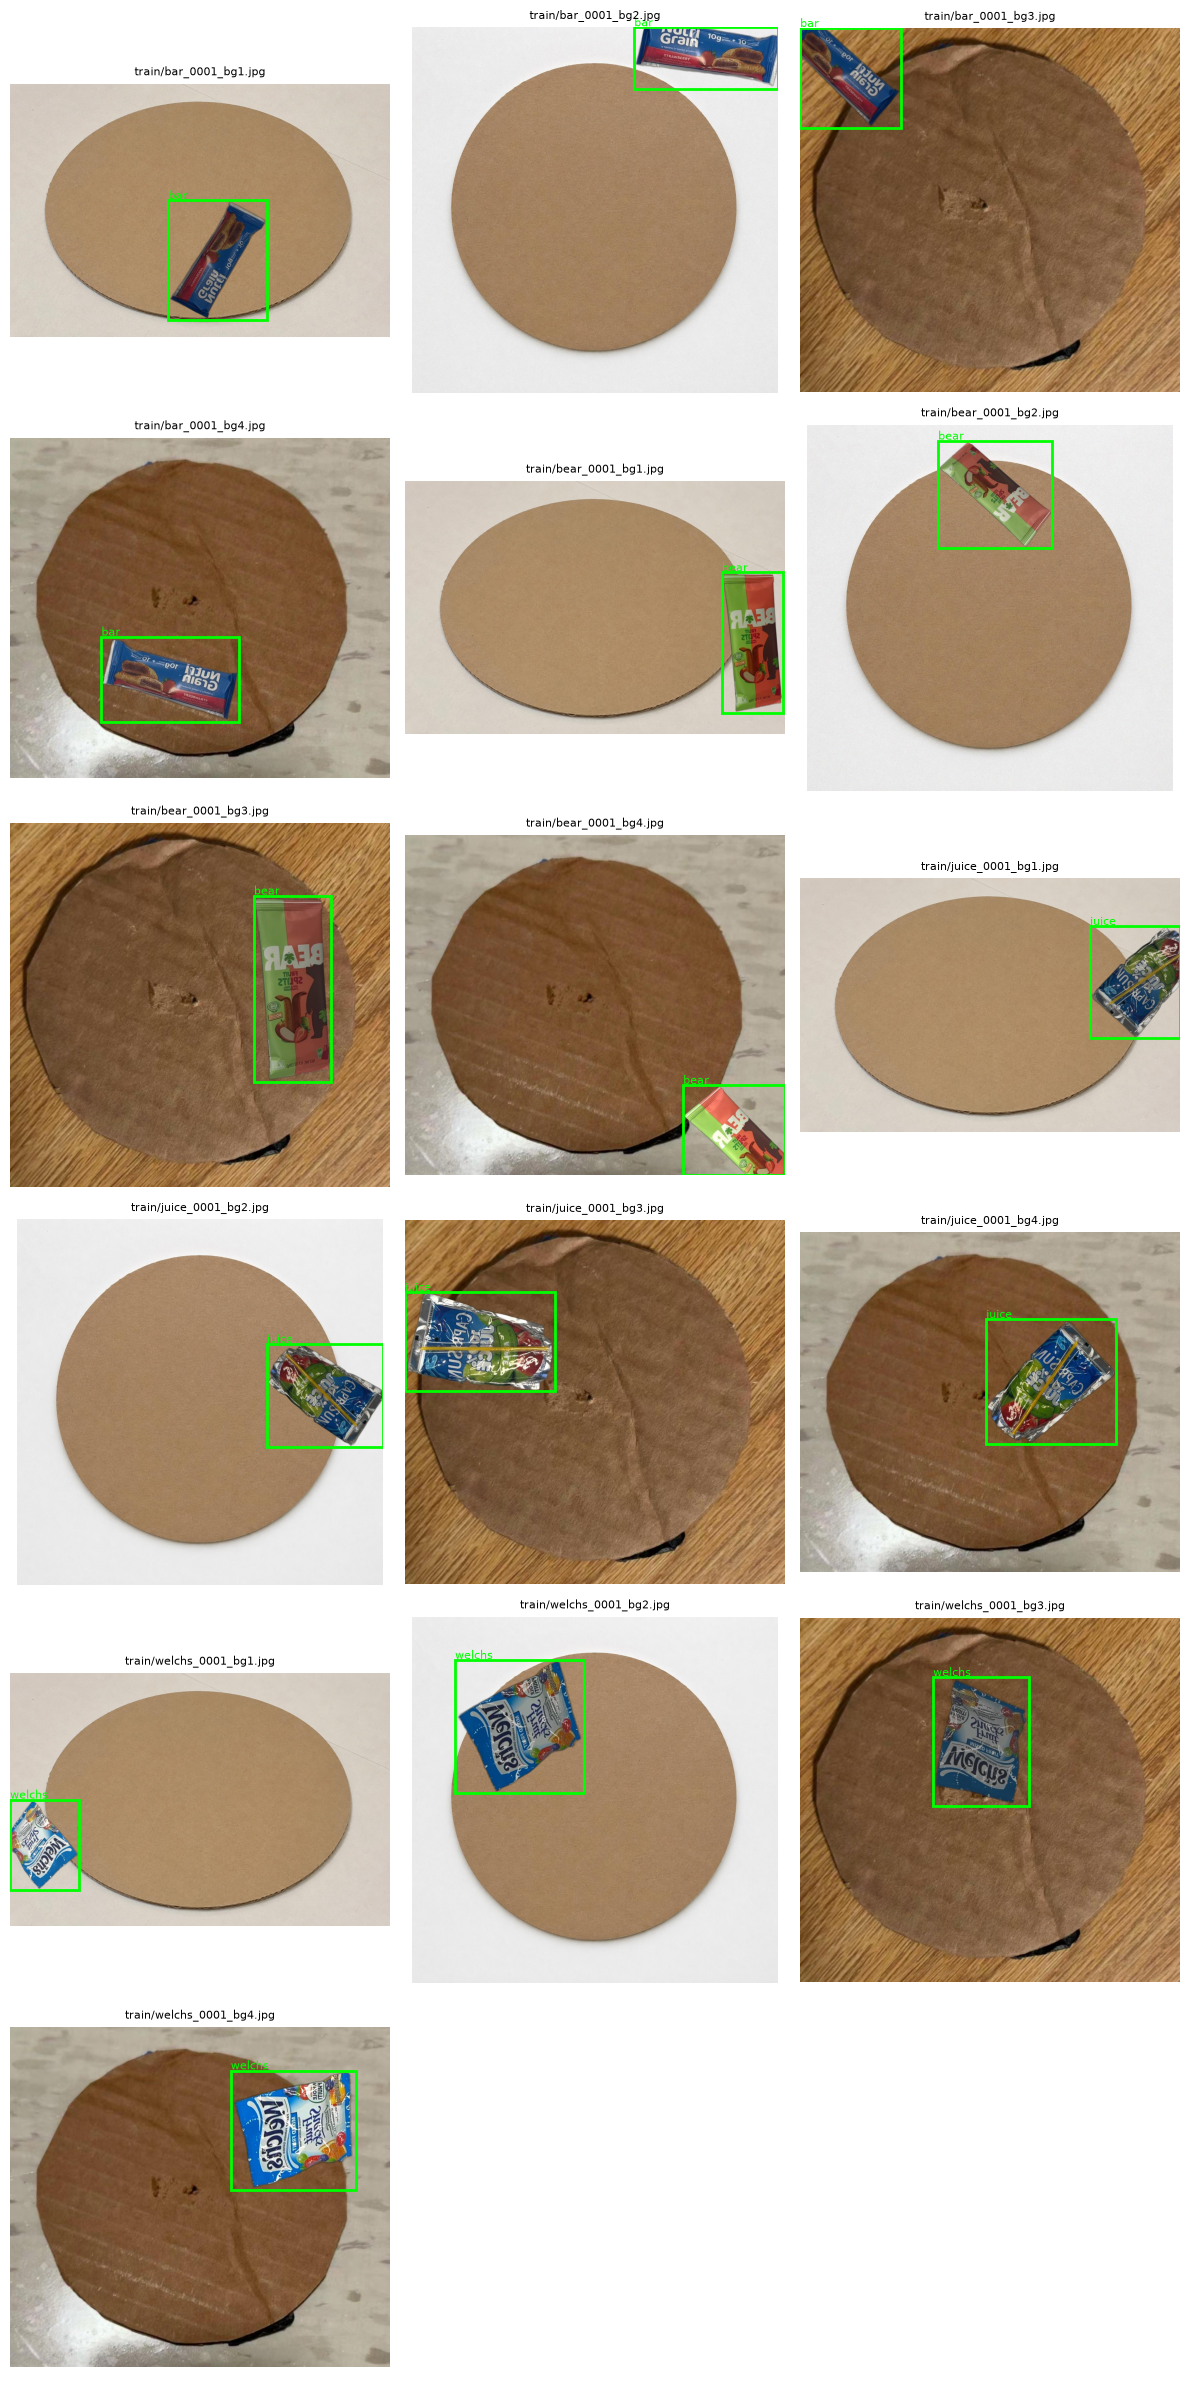

In [6]:
def draw_yolo_grid(images_dir, labels_dir, names, n=9, cols=3):
    # images_dir/labels_dir may contain train/val subfolders (or be flat) —
    # walk recursively so this works for both smoke and full-run layouts.
    files = []
    for root, _, fnames in os.walk(images_dir):
        for fname in fnames:
            if fname.endswith(".jpg"):
                files.append(os.path.relpath(os.path.join(root, fname), images_dir))
    files = sorted(files)[:n]

    rows = math.ceil(len(files) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = np.atleast_1d(axes).flatten()

    for ax, fname in zip(axes, files):
        img = Image.open(os.path.join(images_dir, fname))
        w, h = img.size
        ax.imshow(img)

        label_path = os.path.join(labels_dir, os.path.splitext(fname)[0] + ".txt")
        if os.path.exists(label_path):
            with open(label_path) as f:
                for line in f:
                    cls, xc, yc, bw, bh = map(float, line.split())
                    x0 = (xc - bw / 2) * w
                    y0 = (yc - bh / 2) * h
                    rect = patches.Rectangle((x0, y0), bw * w, bh * h, linewidth=2, edgecolor="lime", facecolor="none")
                    ax.add_patch(rect)
                    ax.text(x0, y0 - 4, names[int(cls)], color="lime", fontsize=8)
        ax.set_title(fname, fontsize=8)
        ax.axis("off")

    for ax in axes[len(files):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()


TEST_OUTPUT = "_dataset_smoke_test"
test_result_dir = generate_synthetic_yolo_dataset(output_folder=TEST_OUTPUT, max_sources_per_class=1)

if test_result_dir:
    with open(os.path.join(test_result_dir, "data.yaml")) as f:
        test_yaml = yaml.safe_load(f)
    draw_yolo_grid(
        os.path.join(test_result_dir, "images"),
        os.path.join(test_result_dir, "labels"),
        test_yaml["names"],
        n=16,
    )


## Sanity check — image/label counts and class list line up

In [7]:
def sanity_check_dataset(output_folder):
    images_dir = os.path.join(output_folder, "images")
    labels_dir = os.path.join(output_folder, "labels")

    def count_by_split(base_dir, ext):
        counts = {}
        for split in ("train", "val"):
            split_dir = os.path.join(base_dir, split)
            counts[split] = len([f for f in os.listdir(split_dir) if f.endswith(ext)]) if os.path.isdir(split_dir) else 0
        return counts

    image_counts = count_by_split(images_dir, ".jpg")
    label_counts = count_by_split(labels_dir, ".txt")
    assert image_counts == label_counts, f"per-split image/label mismatch: images={image_counts} labels={label_counts}"

    with open(os.path.join(output_folder, "data.yaml")) as f:
        data_yaml = yaml.safe_load(f)
    n_images = sum(image_counts.values())
    print(f"OK: {n_images} images {image_counts}, classes = {data_yaml['names']}")


sanity_check_dataset(TEST_OUTPUT)


OK: 16 images {'train': 16, 'val': 0}, classes = {0: 'bar', 1: 'bear', 2: 'juice', 3: 'welchs'}


## Full run

Only run once the smoke-test grid above looks right. Generates 2048 sources
x 4 backgrounds = 8192 images (2048/class, ~1640/410 train/val per class).

In [8]:
RUN_FULL_GENERATION = True  # flip to True to generate the real dataset

if RUN_FULL_GENERATION:
    full_output_dir = generate_synthetic_yolo_dataset(output_folder=OUTPUT_FOLDER)
    sanity_check_dataset(full_output_dir)


Classes: ['bar', 'bear', 'juice', 'welchs']
  bar: 512 sources x 4 backgrounds
  bear: 512 sources x 4 backgrounds
  juice: 512 sources x 4 backgrounds
  welchs: 512 sources x 4 backgrounds



Generated 8192 images.
  bar: 1640 train, 408 val (2048 total)
  bear: 1640 train, 408 val (2048 total)
  juice: 1640 train, 408 val (2048 total)
  welchs: 1640 train, 408 val (2048 total)

Done! Dataset ready in: /snacks_yolo_dataset
OK: 8192 images {'train': 6560, 'val': 1632}, classes = {0: 'bar', 1: 'bear', 2: 'juice', 3: 'welchs'}


## Multi-object composites (2-4 distinct snacks per frame, no occlusion)

The real deployment can show more than one snack on the tray at once. YOLO
already predicts multiple boxes per image natively, but every composite
above has exactly one object — the model has never seen co-occurring
snacks. This section generates a supplementary batch with 2-4 *distinct*
classes per frame (never two of the same class — matches a 4-compartment
tray), placed so no two boxes overlap (with a margin, so they don't even
touch). Written to a **separate staging folder** so it doesn't disturb the
dataset the current training run is reading from; merge it into the main
dataset later.


In [ ]:
MULTI_OUTPUT_FOLDER = "snacks_yolo_dataset_multi"
MULTI_NUM_IMAGES = 2048
MULTI_OBJECTS_RANGE = (2, 4)          # inclusive — distinct classes per frame
MULTI_PLACEMENT_MARGIN_FRAC = 0.15    # keep boxes apart by this fraction of their own size, not just non-touching
MULTI_MAX_PLACEMENT_ATTEMPTS = 20     # per object, before giving up on fitting it into this frame


def boxes_overlap(a, b, margin=0):
    ax0, ay0, ax1, ay1 = a
    bx0, by0, bx1, by1 = b
    return not (ax1 + margin <= bx0 or bx1 + margin <= ax0 or ay1 + margin <= by0 or by1 + margin <= ay0)


def place_one_object(bg_size, fg_path, placed_boxes, margin_frac, max_attempts):
    """Try to pose/scale/place fg_path with zero overlap against placed_boxes.

    Returns (resized_fg_image, (x0, y0, x1, y1)) on success, None if no
    non-overlapping spot was found in max_attempts tries — no edge overlap
    here (unlike the single-object generator), since clipped boxes complicate
    overlap checking and single-object composites already cover that case.
    """
    bg_w, bg_h = bg_size
    fg_img = Image.open(fg_path).convert("RGBA")
    tight_bbox = fg_img.getbbox()
    if not tight_bbox:
        return None
    fg_cropped = fg_img.crop(tight_bbox)

    for _ in range(max_attempts):
        fg_posed = augment_foreground_pose(fg_cropped)
        if fg_posed is None:
            continue
        fg_lit = augment_lighting(fg_posed)

        posed_w, posed_h = fg_lit.size
        aspect_ratio = posed_h / posed_w
        area_frac = random.uniform(*SCALE_AREA_RANGE)
        new_w = int(math.sqrt(area_frac * bg_w * bg_h / aspect_ratio))
        new_h = int(new_w * aspect_ratio)
        if new_w <= 0 or new_h <= 0 or new_w >= bg_w or new_h >= bg_h:
            continue

        max_x, max_y = bg_w - new_w, bg_h - new_h
        paste_x = random.randint(0, max_x)
        paste_y = random.randint(0, max_y)

        margin = int(margin_frac * min(new_w, new_h))
        candidate = (paste_x, paste_y, paste_x + new_w, paste_y + new_h)
        if any(boxes_overlap(candidate, pb, margin) for pb in placed_boxes):
            continue  # retry with a fresh random pose/position/scale

        fg_resized = fg_lit.resize((new_w, new_h), Image.Resampling.LANCZOS)
        return fg_resized, candidate

    return None


def generate_multi_object_dataset(
    fg_class_dirs=None,
    background_files=None,
    output_folder=None,
    num_images=None,
    val_fraction=None,
    seed=None,
):
    fg_class_dirs = fg_class_dirs or DATASET_ROOT
    background_files = background_files or BACKGROUND_FILES
    output_folder = output_folder or MULTI_OUTPUT_FOLDER
    num_images = num_images or MULTI_NUM_IMAGES
    val_fraction = VAL_FRACTION if val_fraction is None else val_fraction
    seed = SEED if seed is None else seed

    random.seed(seed)

    sources_by_class = discover_foreground_sources(fg_class_dirs)
    class_names = sorted(sources_by_class.keys())
    class_to_id = {name: idx for idx, name in enumerate(class_names)}

    images_dir = os.path.join(output_folder, "images")
    labels_dir = os.path.join(output_folder, "labels")
    for split in ("train", "val"):
        os.makedirs(os.path.join(images_dir, split), exist_ok=True)
        os.makedirs(os.path.join(labels_dir, split), exist_ok=True)

    n_val = round(num_images * val_fraction)
    splits = ["val"] * n_val + ["train"] * (num_images - n_val)
    random.shuffle(splits)

    counts = defaultdict(int)
    generated = 0

    for i in range(num_images):
        split = splits[i]
        n_objects = random.randint(*MULTI_OBJECTS_RANGE)
        chosen_classes = random.sample(class_names, min(n_objects, len(class_names)))
        bg_path = random.choice(background_files)

        try:
            bg_img = Image.open(bg_path).convert("RGB")
        except (UnidentifiedImageError, IOError) as e:
            print(f"  WARNING: cannot open '{bg_path}': {e}")
            continue
        bg_stem = os.path.splitext(os.path.basename(bg_path))[0]

        placed_boxes = []
        labels = []
        stems_used = []

        for class_name in chosen_classes:
            fg_path, stem = random.choice(sources_by_class[class_name])
            placement = place_one_object(bg_img.size, fg_path, placed_boxes, MULTI_PLACEMENT_MARGIN_FRAC, MULTI_MAX_PLACEMENT_ATTEMPTS)
            if placement is None:
                continue  # couldn't fit this one without overlap — frame ends up with fewer objects
            fg_resized, box = placement
            bg_img.paste(fg_resized, (box[0], box[1]), fg_resized)
            placed_boxes.append(box)
            stems_used.append(stem)
            labels.append((class_to_id[class_name], box))

        if len(labels) < 2:
            continue  # degenerate frame (couldn't fit at least 2 non-overlapping objects) — skip

        bg_img = augment_composite(bg_img)
        bg_w, bg_h = bg_img.size

        base_filename = "+".join(stems_used) + f"_{bg_stem}"
        generated += 1
        bg_img.save(os.path.join(images_dir, split, f"{base_filename}.jpg"), "JPEG")

        txt_path = os.path.join(labels_dir, split, f"{base_filename}.txt")
        with open(txt_path, "w", encoding="utf-8") as f:
            for class_id, (x0, y0, x1, y1) in labels:
                x_center = (x0 + x1) / 2.0 / bg_w
                y_center = (y0 + y1) / 2.0 / bg_h
                norm_w = (x1 - x0) / bg_w
                norm_h = (y1 - y0) / bg_h
                f.write(f"{class_id} {x_center:.6f} {y_center:.6f} {norm_w:.6f} {norm_h:.6f}\n")

        for class_id, _ in labels:
            counts[(class_names[class_id], split)] += 1

        if generated % 200 == 0:
            print(f"  -> {generated}/{num_images} multi-object frames generated...")

    print(f"\nGenerated {generated} multi-object images (target was {num_images}).")
    for class_name in class_names:
        n_train = counts[(class_name, "train")]
        n_val_c = counts[(class_name, "val")]
        print(f"  {class_name}: {n_train} train, {n_val_c} val instances ({n_train + n_val_c} total)")

    yaml_data = {
        "path": os.path.abspath(output_folder),
        "train": "images/train",
        "val": "images/val",
        "names": {idx: name for name, idx in class_to_id.items()},
    }
    yaml_path = os.path.join(output_folder, "data.yaml")
    with open(yaml_path, "w", encoding="utf-8") as f:
        yaml.dump(yaml_data, f, default_flow_style=False, sort_keys=False)

    print(f"\nDone! Multi-object dataset ready in: /{output_folder}")
    return output_folder


### Intermediary test — small multi-object smoke batch

`draw_yolo_grid`/`sanity_check_dataset` are reused unchanged — both already
handle multi-line label files and train/val subfolders.


In [ ]:
MULTI_TEST_OUTPUT = "_dataset_smoke_test_multi"
multi_test_result_dir = generate_multi_object_dataset(output_folder=MULTI_TEST_OUTPUT, num_images=20)

if multi_test_result_dir:
    with open(os.path.join(multi_test_result_dir, "data.yaml")) as f:
        multi_test_yaml = yaml.safe_load(f)
    draw_yolo_grid(
        os.path.join(multi_test_result_dir, "images"),
        os.path.join(multi_test_result_dir, "labels"),
        multi_test_yaml["names"],
        n=20,
        cols=4,
    )
    sanity_check_dataset(multi_test_result_dir)


### Full multi-object run

Only run once the smoke-test grid above looks right (no overlapping boxes,
each class rendered correctly, no more than one instance of a class per
frame).

In [ ]:
RUN_FULL_MULTI_GENERATION = False  # flip to True to generate the real multi-object supplement

if RUN_FULL_MULTI_GENERATION:
    full_multi_output_dir = generate_multi_object_dataset(output_folder=MULTI_OUTPUT_FOLDER)
    sanity_check_dataset(full_multi_output_dir)
